## Preparación de los datos








In [238]:
import pandas as pd

In [239]:
import warnings
warnings.filterwarnings('ignore')

In [240]:
df = pd.read_csv('/content/datos_tratados.csv')

In [241]:
df.head(2)

,cliente,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,PaymentMethod,cargo mensual,cargo total,Cuentas_Diarias,Gasto_Diario_Historico,internet_Fiber optic,internet_No,telefono_Yes,cancelacion_Yes
0,0002-orfbo,Female,0,Yes,Yes,9,No,No,Yes,No,...,Yes,Mailed check,65.6,593.3,0.029206,2.197407,False,False,True,False
1,0003-mknfe,Male,0,No,No,9,Yes,No,No,No,...,No,Mailed check,59.9,542.4,-0.159990,2.008889,False,False,True,False


#### Eliminación de Columnas

In [242]:
columnas_a_eliminar = ['cliente','cargo total','Gasto_Diario_Historico']

In [243]:
df = df.drop(columns=['cliente','cargo total','Gasto_Diario_Historico'])

Modificación nombre de columnas
Cambio de nombre a español

In [244]:
df = df.rename(columns={
    'gender': 'Genero',
    'SeniorCitizen': 'AdultoMayor',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'MesesContrato',
    'MultipleLines': 'LineasMultiples',
    'OnlineSecurity': 'SeguridadOnline',
    'OnlineBackup': 'RespaldoOnline',
    'DeviceProtection': 'ProteccionDispositivo',
    'PaperlessBilling': 'FacturaDigital',
    'PaymentMethod': 'MetodoPago',
    'cargo mensual': 'CargoMensual',
    'Cuentas_Diarias': 'CargoDiario',
    'internet_Fiber optic': 'InternetFibra',
    'internet_No': 'InternetNo',
    'telefono_Yes': 'Telefono',
    'cancelacion_Yes': 'Cancelacion'
})

In [245]:
df.head(2)

,Genero,AdultoMayor,Pareja,Dependientes,MesesContrato,LineasMultiples,SeguridadOnline,RespaldoOnline,ProteccionDispositivo,TechSupport,...,StreamingMovies,Contract,FacturaDigital,MetodoPago,CargoMensual,CargoDiario,InternetFibra,InternetNo,Telefono,Cancelacion
0,Female,0,Yes,Yes,9,No,No,Yes,No,Yes,...,No,One year,Yes,Mailed check,65.6,0.029206,False,False,True,False
1,Male,0,No,No,9,Yes,No,No,No,No,...,Yes,Month-to-month,No,Mailed check,59.9,-0.159990,False,False,True,False


Limpiar columnas numéricas

In [246]:
cols_num = ['AdultoMayor', 'CargoMensual', 'CargoDiario', 'MesesContrato']

for col in cols_num:
    df[col] = (
        df[col]
        .astype(str)        # asegurar que sea texto
        .str.strip()        # eliminar espacios
        .replace('', None)  # convertir vacío a NaN
    )

    # convertir a número
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [247]:
df['Cancelacion'].value_counts(normalize=True)

,proportion
Cancelacion,
False,0.74281
True,0.25719


####Limpieza de variable Cancelación (Churn)

In [248]:
df['Cancelacion'].isnull().sum()

np.int64(0)

In [249]:
df['Cancelacion'].isnull().any()

np.False_

Verificación que existan nulos

In [250]:
df.isnull().sum()

,0
Genero,0
AdultoMayor,0
Pareja,0
Dependientes,0
MesesContrato,0
LineasMultiples,0
SeguridadOnline,0
RespaldoOnline,0
ProteccionDispositivo,0
TechSupport,0


## Encoding

#### One-Hot Encoding (más común)
Convierte cada categoría en una columna binaria (0/1).

In [251]:
df['Cancelacion'] = df['Cancelacion'].map({
    True: 1,
    False: 0
})

In [252]:
df['Cancelacion'].value_counts(dropna=False)

,count
Cancelacion,
0,5398
1,1869


Separar variables predictoras y variables objetivo

In [253]:
# Separar X e y
X = df.drop('Cancelacion', axis=1)
y = df['Cancelacion']

In [254]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [255]:
X.select_dtypes(include=['object']).columns

Index(['Genero', 'Pareja', 'Dependientes', 'LineasMultiples',
       'SeguridadOnline', 'RespaldoOnline', 'ProteccionDispositivo',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'FacturaDigital', 'MetodoPago'],
      dtype='object')

Usando pd.get_dummies() (más simple)

In [256]:
X_encoded = pd.get_dummies(X, drop_first=True)

####Usando OneHotEncoder dentro de Pipeline


In [257]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identificar columnas
columnas_numericas = X.select_dtypes(include=['int64','float64']).columns
columnas_categoricas = X.select_dtypes(include=['object']).columns

preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), columnas_categoricas) # evita errore si aparece una categoria nueva en test
    ]
)


Se aplicó One-Hot Encoding para convertir variables categóricas en representaciones numéricas binarias, permitiendo su uso en modelos de clasificación sin asumir relación ordinal entre categorías.

Recomendación estratégica

 Usar ColumnTransformer

 Integrarlo luego dentro de Pipeline con el modelo

In [258]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_log = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000))
])

pipeline_log.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['AdultoMayor', 'MesesContrato', 'CargoMensual', 'CargoDiario'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Genero', 'Pareja', 'Dependientes', 'LineasMultiples',
       'SeguridadOnline', 'RespaldoOnline', 'ProteccionDispositivo',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'FacturaDigital', 'MetodoPago'],
      dtype='object'))])),
                ('modelo', LogisticRegression(max_iter=1000))])

## Verificación de la proporción de cancelación (Churn)

#### Cuántos clientes cancelaron y los que  no cancelaron

In [259]:
# Conteo de clientes que cancelaron vs los que permanecieron
df['Cancelacion'].value_counts()

,count
Cancelacion,
0,5398
1,1869


In [260]:
(df['Cancelacion'].value_counts(normalize=True)*100).round(2)

,proportion
Cancelacion,
0,74.28
1,25.72


74% clientes permanecen

25% clientes cancelan

Visualización

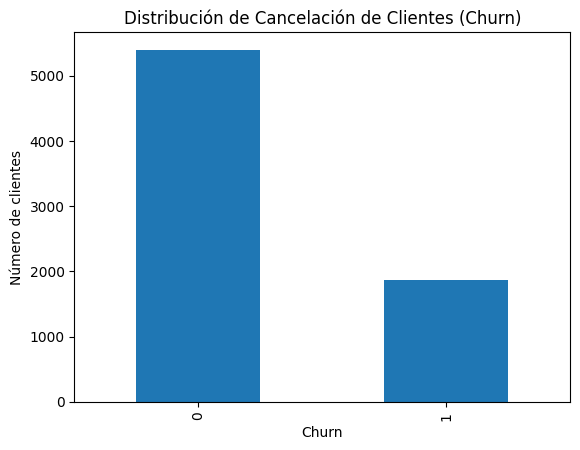

In [261]:
import matplotlib.pyplot as plt

df['Cancelacion'].value_counts().plot(
    kind='bar',
    title='Distribución de Cancelación de Clientes (Churn)',
)

plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.show()

#### Interpretación

El análisis de la variable objetivo muestra que aproximadamente 74% de los clientes permanecen activos, mientras que cerca del 25% han cancelado el servicio.
Esto indica un desbalance moderado entre las clases, lo cual es común en problemas de churn y debe considerarse al evaluar el desempeño de los modelos predictivos.

⚠️ ¿Es grave este desbalance?

Regla general:

Proporción	Interpretación

50 / 50	balanceado

70 / 30	desbalance leve

90 / 10	desbalance fuerte

Tu caso (aprox 74 / 25) es bastante manejable.


#### Balanceo de Clases

####Oversampling (aumentar la clase minoritaria)
Duplica o replica ejemplos de la clase minoritaria

In [262]:
from sklearn.utils import resample

# Combinar X e y
data = pd.concat([X_encoded, y], axis=1)

# Separar clases
mayoria = data[data['Cancelacion'] == 0]
minoria = data[data['Cancelacion'] == 1]

# Oversampling
minoria_oversample = resample(
    minoria,
    replace=True,
    n_samples=len(mayoria),
    random_state=42
)

# Nuevo dataset balanceado
data_balanceado = pd.concat([mayoria, minoria_oversample])

# Separar nuevamente
X_bal = data_balanceado.drop('Cancelacion', axis=1)
y_bal = data_balanceado['Cancelacion']


In [263]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_bal, y_bal = smote.fit_resample(X_encoded, y)

In [264]:
y_bal.value_counts()

,count
Cancelacion,
0,5398
1,5398


####Undersampling (reducir la clase mayoritaria)
Se eliminan ejemplos de la clase mayoritaria

In [265]:
mayoria_undersample = resample(
    mayoria,
    replace=False,
    n_samples=len(minoria),
    random_state=42
)

data_balanceado = pd.concat([mayoria_undersample, minoria])

X_bal = data_balanceado.drop('Cancelacion', axis=1)
y_bal = data_balanceado['Cancelacion']


In [266]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_res, y_res = rus.fit_resample(X_train, y_train)


In [267]:
y_res.value_counts()

,count
Cancelacion,
0,1497
1,1497


####SMOTE (la tecnica más usada en Machine Learning)
Genera datos sintéticos de la clase minoritaria en lugar de duplicados

Debido al desbalance existente entre clientes que cancelan y aquellos que permanecen activos, se aplicó la técnica SMOTE (Synthetic Minority Over-sampling Technique) para generar ejemplos sintéticos de la clase minoritaria. Esto permite entrenar modelos más equilibrados y mejorar la capacidad de detectar clientes con riesgo de cancelación.

## Normalización /estandarización

#### Aplicar estandarización con StandarScaler

Algunos algoritmos dependen de la distancia entre variables, por lo que necesitan que todas estén en la misma escala.

Modelos que sí requieren estandarización

Regresión Logística

KNN

SVM

Redes neuronales

Porque utilizan distancias o gradientes.

Modelos que NO necesitan estandarización

Decision Tree

Random Forest

XGBoost

Estos modelos usan divisiones por umbral, por lo que la escala de las variables no afecta el resultado.

Qué hacer
Con Logistic Regression y Random Forest, la práctica correcta es:

✔ Estandarizar solo las variables numéricas

✔ No tocar las variables dummy generadas por one-hot encoding

####Aplicar estandarización con StandardScaler

Primero identificamos variables numéricas.

In [268]:
numericas = df.select_dtypes(include=['int64', 'float64']).columns

print("Columnas numéricas detectadas:")
print(numericas)

Columnas numéricas detectadas:
Index(['AdultoMayor', 'MesesContrato', 'CargoMensual', 'CargoDiario',
       'Cancelacion'],
      dtype='object')


In [269]:
# Identificación de variables numéricas
from sklearn.preprocessing import StandardScaler

columnas_numericas = ['AdultoMayor', 'CargoMensual', 'CargoDiario', 'MesesContrato']

Aplicamos el escalado:

In [270]:
scaler = StandardScaler()

X_encoded[columnas_numericas] = scaler.fit_transform(X_encoded[columnas_numericas])

In [271]:
X_encoded[columnas_numericas].describe()

,AdultoMayor,CargoMensual,CargoDiario,MesesContrato
count,7.267000e+03,7.267000e+03,7.267000e+03,7.267000e+03
mean,-1.016877e-16,7.333247e-17,1.466649e-18,-3.911065e-17
std,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00
min,-4.407359e-01,-1.542448e+00,-1.542448e+00,-1.316499e+00
25%,-4.407359e-01,-9.723707e-01,-9.723707e-01,-9.502002e-01
50%,-4.407359e-01,1.852096e-01,1.852096e-01,-1.362021e-01
75%,-4.407359e-01,8.349482e-01,8.349482e-01,9.219954e-01
max,2.268932e+00,1.793375e+00,1.793375e+00,1.613894e+00


Se aplicó estandarización mediante StandardScaler a las variables numéricas para garantizar que todas tengan media cero y desviación estándar uno. Este paso es necesario para modelos sensibles a la escala de los datos, como Regresión Logística, evitando que variables con magnitudes mayores influyan desproporcionadamente en el modelo.

## Correlación y Selección de Variables

#### Seleccionar sólo variables numéricas

In [272]:
variables_numericas = df.select_dtypes(include=['int64','float64'])

variables_numericas.head()

,AdultoMayor,MesesContrato,CargoMensual,CargoDiario,Cancelacion
0,0,9,65.6,0.029206,0
1,0,9,59.9,-0.159990,0
2,0,4,73.9,0.304702,1
3,1,13,98.0,1.104635,1
4,1,3,83.9,0.636624,1


#### Calcular matriz de correlación

Esto calcula la correlación de Pearson entre todas las variables numéricas:

Estos van de valor

1 correlación positiva perfecta.

0 hay correlación

-1 correlación negativa perfecta

In [273]:
matriz_corr = variables_numericas.corr()
matriz_corr

,AdultoMayor,MesesContrato,CargoMensual,CargoDiario,Cancelacion
AdultoMayor,1.000000,0.018187,0.220388,0.220388,0.146733
MesesContrato,0.018187,1.000000,0.247982,0.247982,-0.344079
CargoMensual,0.220388,0.247982,1.000000,1.000000,0.189866
CargoDiario,0.220388,0.247982,1.000000,1.000000,0.189866
Cancelacion,0.146733,-0.344079,0.189866,0.189866,1.000000


#### Visualizar matriz con Heatman

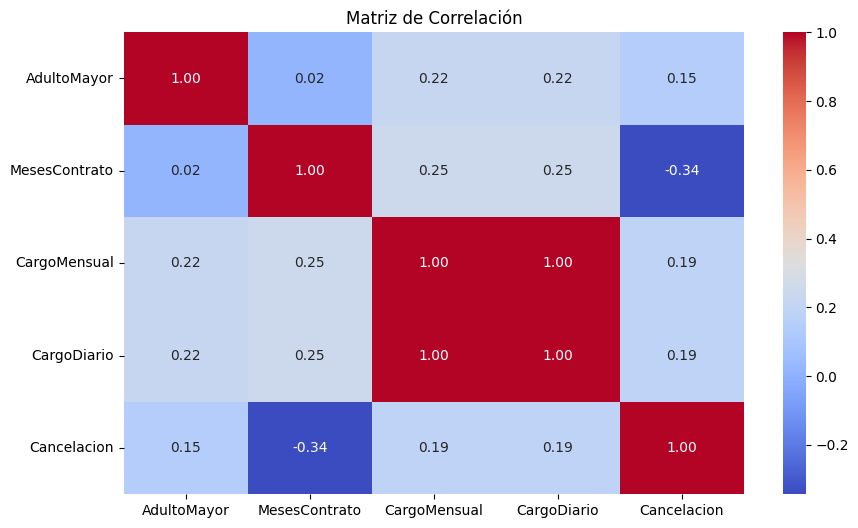

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"                       # 1 correlación positiva perfecah
)                                   # 0 no hay relación
                                    # -1 correlación negativa perfecta
plt.title("Matriz de Correlación")
plt.show()

La matriz de correlación muestra una correlación perfecta (1.00) entre las variables CargoMensual y CargoDiario.

Esto ocurre porque la variable de cargos diarios fue calculada directamente a partir de los cargos mensuales, lo que genera una relación matemática exacta. Debido a esta redundancia, se decidió mantener únicamente una de estas variables para evitar problemas de multicolinealidad en el análisis y los modelos predictivos.

El factor más asociado a la Cancelación en las variables numéricas es:

MesesContrato = -0.34

Esto significa que los clientes nuevos cancelan más que los antiguos.
Este suele ser uno de los hallazgos más importantes en el análisis de churn.


####Correlación específica con Churn

In [275]:
matriz_corr['Cancelacion'].sort_values(ascending=False)

,Cancelacion
Cancelacion,1.000000
CargoMensual,0.189866
CargoDiario,0.189866
AdultoMayor,0.146733
MesesContrato,-0.344079


#### Interpretación típica en churn

**MesesContrato** (-0.344)

Es la correlación negativa más fuerte con la cancelación.

✔ Clientes con más tiempo en la empresa cancelan menos
✔ Clientes nuevos cancelan más

Esto es muy común en análisis de churn porque los clientes recién adquiridos aún no están fidelizados.


**CargoMensual** (0.189)

Tiene una correlación positiva débil.

✔ Clientes con cargos mensuales más altos tienen mayor probabilidad de cancelar.

✔ Percepción de precio alto
✔ Comparación con competidores

**CargoDiario** (0.189)

Tiene exactamente la misma correlación que CargoMensual.

✔ A mayor costo o frecuencia de facturación, mayor probabilidad de churn.

**AdultoMayor** (0.14)

Tiene una correlación positiva débil.

✔ Los clientes mayores presentan ligeramente mayor probabilidad de cancelación.

Pero el impacto no es fuerte, por lo que no es un factor determinante.

##Identificación de variables importantes

####Variables con mayor correlación absoluta con **Cancelaciones** son buenas candidatas para el modelo

In [276]:
corr_churn = matriz_corr['Cancelacion'].abs().sort_values(ascending=False)

corr_churn

,Cancelacion
Cancelacion,1.000000
MesesContrato,0.344079
CargoMensual,0.189866
CargoDiario,0.189866
AdultoMayor,0.146733


In [277]:
corr_churn[1:10]  #Se quita la correlación consigo mismo

,Cancelacion
MesesContrato,0.344079
CargoMensual,0.189866
CargoDiario,0.189866
AdultoMayor,0.146733


####Interpretación

Se analizó la matriz de correlación entre las variables numéricas del dataset.

Se observó que variables como **MesesContrato**, **CargoMensual** y **CargoDiario** presentan una relación relevante con la cancelación de clientes.

En particular, la variable **MesesContrato** muestra una correlación negativa con el churn, indicando que los clientes con mayor antigüedad tienden a cancelar menos sus servicios.

####Análisis Dirigido

####Tiempo de contrato (MesesContrato) vs Cancelación

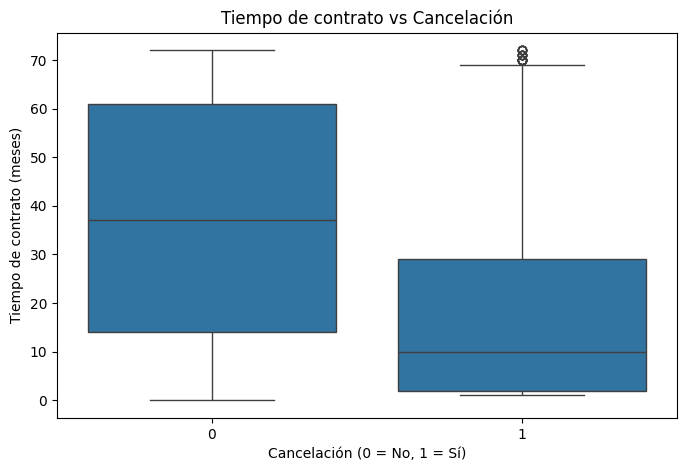

In [278]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cancelacion',
    y='MesesContrato',
    data=df
)

plt.title('Tiempo de contrato vs Cancelación')
plt.xlabel('Cancelación (0 = No, 1 = Sí)')
plt.ylabel('Tiempo de contrato (meses)')

plt.show()

Normalmente se observa que:

Los clientes que cancelan tiene menos meses de contrato.

Los clientes que no cancelan tienen mayor permanencia.

Gasto Mensual vs Cancelacion

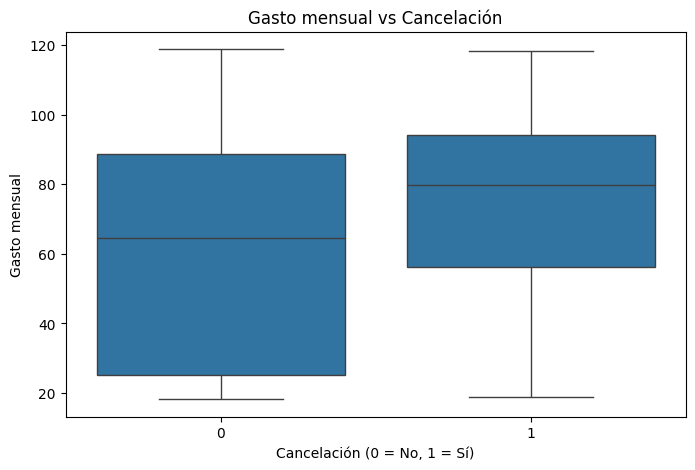

In [279]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cancelacion',
    y='CargoMensual',
    data=df
)

plt.title('Gasto mensual vs Cancelación')
plt.xlabel('Cancelación (0 = No, 1 = Sí)')
plt.ylabel('Gasto mensual')

plt.show()


Se observa:

✔ Clientes que han gastado más dinero  tienden a quedarse

✔ Clientes con bajo gasto total cancelan con mayor frecuencia

Esto suele estar relacionado con la antigüedad del cliente, factor importante en la retención

####Alternativa: Scatter Plot (opcional)

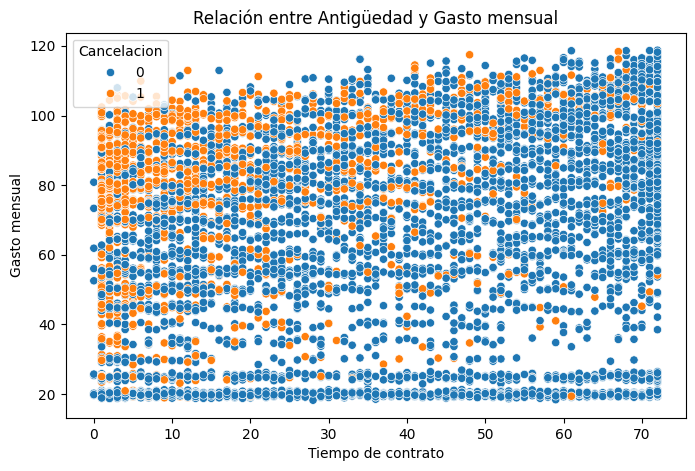

In [280]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='MesesContrato',
    y='CargoMensual',
    hue='Cancelacion',
    data=df
)

plt.title('Relación entre Antigüedad y Gasto mensual')
plt.xlabel('Tiempo de contrato')
plt.ylabel('Gasto mensual')

plt.show()

#####Este gráfico permite ver cómo se agrupan los clientes que cancelan vs los que no.

####Interpretación

El análisis visual muestra que los clientes con menor antigüedad (**MesesContrato**) presentan mayor probabilidad de cancelar el servicio. Asimismo, los clientes con menor **GastoMensual** acumulado tienden a abandonar con mayor frecuencia.
Estos resultados sugieren que los clientes nuevos representan un grupo de mayor riesgo de cancelación.



##Modelado Predictivo

####Separación de Datos (Train / Test)

Entrenamiento (Train) → el modelo aprende patrones.

Prueba (Test) → evaluamos qué tan bien predice.

La división más común es:
70% entrenamiento
30% prueba

In [281]:
from sklearn.model_selection import train_test_split

####Definir variables predictoras y variable objetivo
Recordemos:

✔ X → variables que explican el churn

✔ y → variable objetivo (Cancelaciones)

In [282]:
X = X_encoded
y = df['Cancelacion']

####Dividir el dataset

In [283]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

####Qué significa cada parámetro


**test_size=0.30**
30% de datos para prueba

**random_state=42**
asegura resultados reproducibles

**stratify=y**
mantiene la proporción de churn
Esto es muy importante en problemas con desbalance de clases.

In [284]:
print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (5086, 30)
Tamaño prueba: (2181, 30)


####Verificar proporción de churn
Esto confirma que **stratify** funcionó

In [285]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
Cancelacion
0    0.742823
1    0.257177
Name: proportion, dtype: float64

Test:
Cancelacion
0    0.742779
1    0.257221
Name: proportion, dtype: float64


####Interpretación

El conjunto de datos fue dividido en 70% para entrenamiento y 30% para prueba utilizando la función **train_test_split** de Scikit-learn. Se utilizó el parámetro stratify para mantener la proporción de clientes que cancelan y los que permanecen activos en ambos subconjuntos, garantizando una evaluación más representativa del modelo.

##Creación Modelos Predictivos

####**Modelo 1: Regresión Logística**
Este modelo es uno de los más usados para problemas de clasificación binaria como churn.

In [286]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

####Predicciones con **Regresión Logística**

Ahora se usa los datos de prueba

In [287]:
y_pred_log = modelo_logistico.predict(X_test)
y_pred_log

array([0, 0, 1, ..., 1, 1, 0])

####Evaluación del Modelo

In [288]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [289]:
print("Evaluación - Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log))

Evaluación - Regresión Logística
Accuracy: 0.8000917010545622
Precision: 0.6338329764453962
Recall: 0.5276292335115864
F1-score: 0.5758754863813229

Matriz de Confusión:
[[1449  171]
 [ 265  296]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1620
           1       0.63      0.53      0.58       561

    accuracy                           0.80      2181
   macro avg       0.74      0.71      0.72      2181
weighted avg       0.79      0.80      0.79      2181



|     |  Predijo No Cancela | Predijo Cancela |
| ---------- | ------------------ | --------------- |
| No cancela | **1449**           | 171             |
| Cancela    | 265                | **296**         |
Significa:

1449 clientes correctamente identificados como no cancelación

296 clientes correctamente identificados como cancelación

171 falsos positivos

265 falsos negativos

| Métrica   | Valor    | Interpretación                                   |
| --------- | -------- | ------------------------------------------------ |
| Accuracy  | **0.80** | buen desempeño general                           |
| Precision | **0.63** | moderado                                         |
| Recall    | **0.53** | el modelo detecta solo la mitad de cancelaciones |
| F1-score  | **0.57** | rendimiento medio  
                            

El modelo detecta mejor a los clientes que NO cancelan que a los que cancelan.

Esto es muy común en problemas de churn porque las clases suelen estar desbalanceadas.

El modelo de regresión logística alcanzó una precisión global del 80 %. Sin embargo, el recall para la clase de cancelación es del 53 %, lo que indica que el modelo aún presenta dificultades para identificar correctamente todos los clientes que cancelan el servicio. Esto sugiere la necesidad de mejorar el modelo mediante técnicas adicionales de balanceo de clases o el uso de algoritmos más robustos.

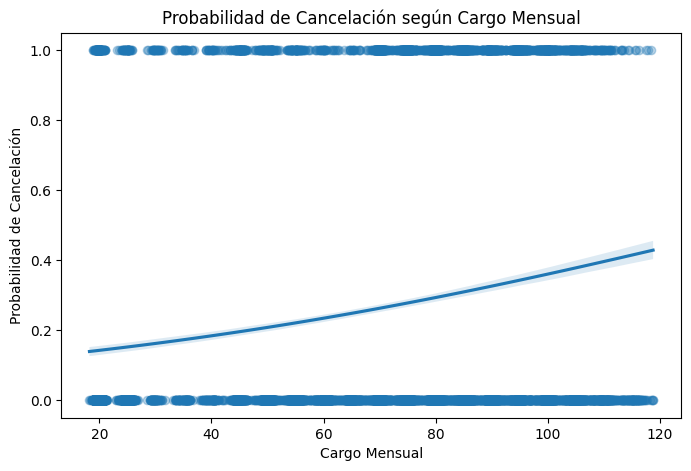

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.regplot(
    x='CargoMensual',
    y='Cancelacion',
    data=df,
    logistic=True,
    scatter_kws={'alpha':0.3}
)

plt.title('Probabilidad de Cancelación según Cargo Mensual')
plt.xlabel('Cargo Mensual')
plt.ylabel('Probabilidad de Cancelación')

plt.show()


Qué muestra este gráfico

Los puntos representan clientes

La línea muestra la probabilidad estimada de cancelación

Si la línea sube → a mayor precio, mayor riesgo de churn


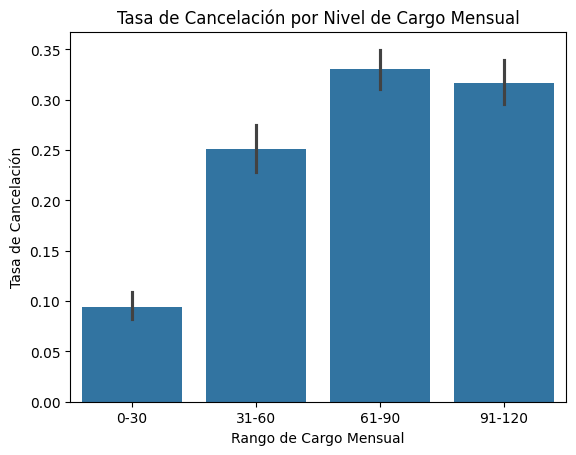

In [291]:
df['RangoCargo'] = pd.cut(
    df['CargoMensual'],
    bins=[0,30,60,90,120],
    labels=['0-30','31-60','61-90','91-120']
)

sns.barplot(
    x='RangoCargo',
    y='Cancelacion',
    data=df
)

plt.title('Tasa de Cancelación por Nivel de Cargo Mensual')
plt.xlabel('Rango de Cargo Mensual')
plt.ylabel('Tasa de Cancelación')

plt.show()


Este gráfico muestra directamente el porcentaje de cancelación por rango de precio.


El análisis de la relación entre los cargos mensuales y la cancelación del servicio muestra una tendencia creciente en la probabilidad de churn a medida que aumenta el costo mensual. Esto sugiere que los clientes con tarifas más altas presentan mayor probabilidad de abandonar el servicio, lo que podría estar asociado a la percepción de alto costo o a la disponibilidad de ofertas competitivas en el mercado.

#### **Modelo 2: Random Forest**

Random Forest es un modelo basado en múltiples árboles de decisión.

In [292]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

####Predicciones con **Random Forest**

In [293]:
y_pred_rf = modelo_rf.predict(X_test)

####Evaluación del modelo

In [294]:
print("Evaluación - Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

Evaluación - Random Forest
Accuracy: 0.7808344795965153
Precision: 0.5958429561200924
Recall: 0.45989304812834225
F1-score: 0.5191146881287726

Matriz de Confusión:
[[1445  175]
 [ 303  258]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1620
           1       0.60      0.46      0.52       561

    accuracy                           0.78      2181
   macro avg       0.71      0.68      0.69      2181
weighted avg       0.77      0.78      0.77      2181



####Interpretar la Matriz de Confusión

Interpretación de las métricas

🔹 Accuracy = 0.78

El modelo clasifica correctamente el 78 % de los clientes.

Es un resultado aceptable, pero ligeramente menor que la regresión logística (0.80).

🔹 Precision = 0.60

De todos los clientes que el modelo predijo como cancelación, el 60 % realmente canceló.

Esto indica precisión moderada.

🔹 Recall = 0.46

El modelo detecta solo 46 % de los clientes que cancelan.

Esto significa que más de la mitad de los clientes que cancelan no son detectados.

En churn esto es importante porque el objetivo suele ser identificar clientes en riesgo antes de que se vayan.

🔹 F1-score = 0.52

El F1-score combina precision y recall, por lo que refleja el balance del modelo.

Un 0.52 indica desempeño moderado.

|            | Predijo No Cancela | Predijo Cancela |
| ---------- | ------------------ | --------------- |
| No cancela | **1445**           | 175             |
| Cancela    | 303                | **258**         |



Interpretación:

1445 clientes correctamente clasificados como no cancelación

258 clientes correctamente identificados como cancelación

175 falsos positivos

303 falsos negativos

El modelo pierde muchos clientes que sí cancelan.

####Evaluación de los Modelos

####Comparación con Regresión Logística

| Modelo              | Accuracy | Precision | Recall   | F1       |
| ------------------- | -------- | --------- | -------- | -------- |
| Regresión Logística | **0.80** | **0.63**  | **0.53** | **0.57** |
| Random Forest       | 0.78     | 0.60      | 0.46     | 0.52     |


Conclusión:

 La regresión logística tuvo mejor desempeño en todas las métricas.

Esto puede pasar porque:

el dataset tiene relaciones bastante lineales

el Random Forest no fue optimizado (hiperparámetros por defecto)

####Insight importante del análisis

Ambos modelos muestran algo similar:

✔ detectan bien a los clientes que no cancelan.

⚠ tienen más dificultad para detectar a los que sí cancelan

Esto suele ocurrir por:

✔desbalance de clases

✔patrones de churn complejos

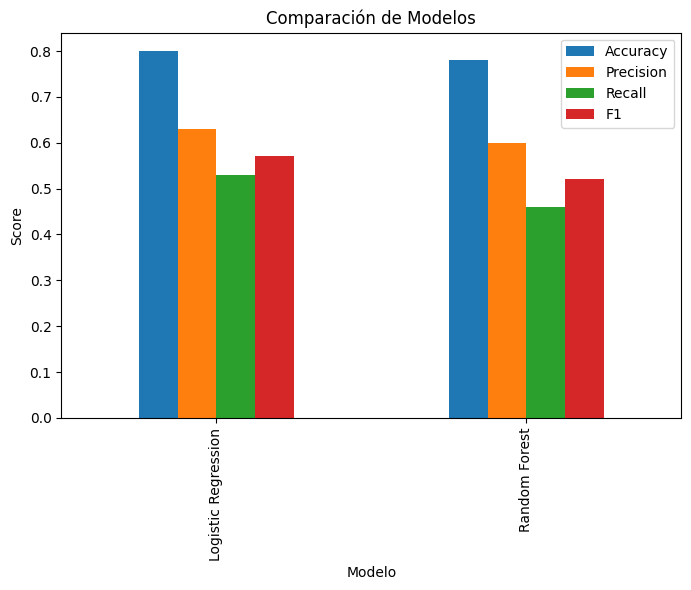

In [295]:
modelos = pd.DataFrame({
    'Modelo':['Logistic Regression','Random Forest'],
    'Accuracy':[0.80,0.78],
    'Precision':[0.63,0.60],
    'Recall':[0.53,0.46],
    'F1':[0.57,0.52]
})

modelos.set_index('Modelo').plot(kind='bar', figsize=(8,5))

plt.title("Comparación de Modelos")
plt.ylabel("Score")

plt.show()


Overfitting (sobreajuste)

El modelo aprende demasiado bien los datos de entrenamiento pero no generaliza.

Se detecta cuando:

Accuracy muy alta en entrenamiento

Accuracy mucho menor en test

Underfitting (subajuste)

El modelo no logra aprender el patrón.

Se detecta cuando:

Accuracy baja en train

Accuracy baja en test

Qué está pasando realmente en el modelo

Clase 0 (no cancelan)

Muy buen desempeño:

Precision: 0.83

Recall: 0.89

Detecta bien a quienes no cancelan.

Clase 1 (cancelación)

Más difícil para el modelo:

Precision: 0.60

Recall: 0.46

Esto significa:

De 561 cancelaciones reales, el modelo detecta 258.

Es decir:

258/561≈46%

Detecta menos de la mitad.

¿Hay overfitting?

Por ahora no parece haber overfitting fuerte, porque:

Accuracy 0.78 es razonable

F1-score coherente

Random Forest suele generalizar bien

¿Hay underfitting?

Tampoco parece underfitting porque:

Accuracy relativamente buena

El modelo aprende patrones

El problema principal es desbalance de clases.

El verdadero problema: detectar cancelaciones

El modelo es bueno para predecir clientes que NO cancelan, pero más débil para cancelaciones.

####Algo importante: el modelo no está mal

De hecho para problemas de cancelación es bastante normal tener:

Accuracy 0.75 – 0.82

F1 clase 1 entre 0.45 – 0.60

El modelo está dentro de un rango realista.

##Interpretación: Importancia de las variables

#### **Importancia en Random Forest**

Random Forest permite ver qué variables influyen más en la cancelación (Churn)

In [296]:
# Obtener importancia de variables
importancias = modelo_rf.feature_importances_

# Crear dataframe
df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
})

# Ordenar
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

print(df_importancia.head(10))

                       Variable  Importancia
1                 MesesContrato     0.209095
2                  CargoMensual     0.165270
3                   CargoDiario     0.162891
28  MetodoPago_Electronic check     0.039276
25            Contract_Two year     0.033252
4                 InternetFibra     0.031901
7                   Genero_Male     0.030344
26           FacturaDigital_Yes     0.026228
13          SeguridadOnline_Yes     0.025804
19              TechSupport_Yes     0.025303


####Gráfico de importancia

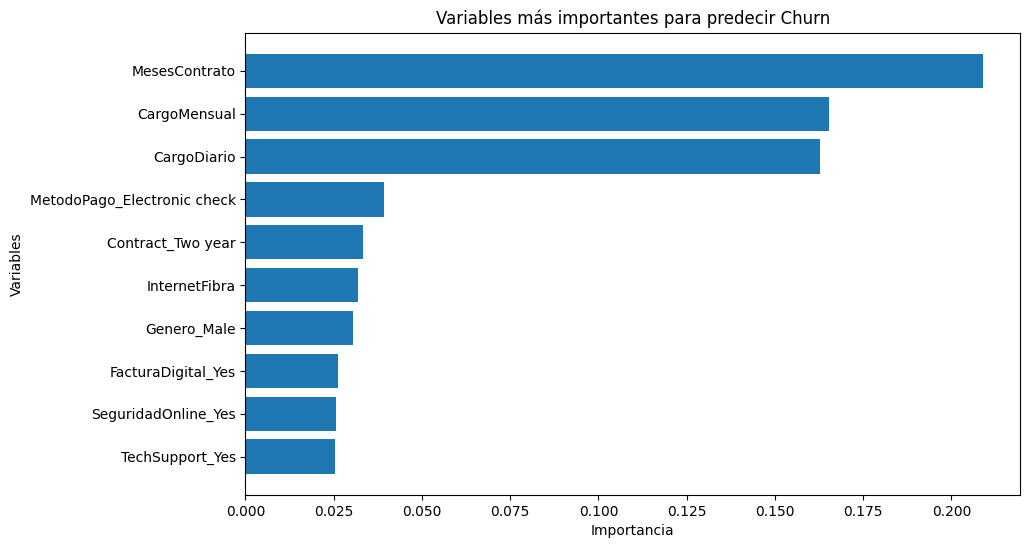

In [297]:
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.barh(df_importancia['Variable'][:10], df_importancia['Importancia'][:10])

plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.title("Variables más importantes para predecir Churn")

plt.gca().invert_yaxis()

plt.show()

####**Análisis de los Resultados**

1.-Antigüedad del cliente **MesesContrato**(0.209)

✔ Clientes con menos meses en la empresa cancelan más.
✔ Clientes antiguos son más leales.

####2.- Gasto mensual **CargoMensual**(0.165)

✔Precios altos aumentan probabilidad de cancelación.
Clientes con tarifas más altas suelen más cambiar de proveedor.

####3.-**CargoDiario**(0.163)

Esto confirma que en la matriz de correlación estas variables están muy correlacionadas.

**CargoDiario=CargoMensual/30**

####4. **Variables relacionadas con contrato**

**Contract_Two year**

✔Clientes con contratos largos cancelan menos.

####5. **Método de pago**

**MetodoPago_Electronic check**

Clientes que pagan con electronic check suelen tener:

✔mayor churn

✔menor compromiso con el servicio

####6.  **Servicios adicionales**

Variables como:

✔SeguridadOnline

✔TechSupport

✔Interpretación:

Clientes que tienen más servicios asociados:

✔Usan más el servicio

✔Tienen menos probabilidad de cancelar

####7. **Algo interesante: género aparece**

✔Genero_Male

Importancia: 0.030

Esto indica que el modelo detecta alguna diferencia leve, pero es mucho menos relevante que:

✔Duración del contrato

✔Costos

✔Tipo de servicio

####Conclusión del análisis de variables

El análisis de importancia del modelo **Random Forest** muestra que los factores más relevantes para predecir la cancelación de clientes son la duración del contrato (MesesContrato) y los costos del servicio (CargoMensual, CargoDiario).

Los clientes con menor antigüedad presentan mayor probabilidad de cancelar el servicio. Asimismo, los cargos mensuales más altos incrementan la probabilidad de abandono.

Variables relacionadas con el tipo de contrato, método de pago y servicios adicionales también influyen en el comportamiento de cancelación, aunque en menor medida.

####**Importancia en Regresión Logística**
La regresión logística usa coeficientes.

In [298]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train, y_train)


coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

print(coeficientes.head(10))

                              Variable  Coeficiente
4                        InternetFibra     1.156824
23                 StreamingMovies_Yes     0.418450
26                  FacturaDigital_Yes     0.383310
11                 LineasMultiples_Yes     0.374636
21                     StreamingTV_Yes     0.372013
28         MetodoPago_Electronic check     0.340503
17           ProteccionDispositivo_Yes     0.111343
0                          AdultoMayor     0.077562
27  MetodoPago_Credit card (automatic)    -0.034199
8                           Pareja_Yes    -0.045336


En regresión logística:

Coeficiente positivo (+) → aumenta la probabilidad de cancelación

Coeficiente negativo (-) → reduce la probabilidad de cancelación

Valor cercano a 0 → poco impacto

Mientras más grande sea el coeficiente, mayor influencia tiene la variable.

####**Variables que MÁS aumentan la cancelación**

**InternetFibra (1.156)**

Los clientes con internet de fibra tienen mayor probabilidad de cancelar.

Esto puede deberse a:

✔Mayor costo

✔Mayor competencia en ese servicio

✔Expectativas más altas del cliente

**StreamingMovies (0.418)** texto en negrita

Clientes que tienen streaming de películas:

✔Tienen mayor probabilidad de cancelar

Posible explicación:

✔Mayor uso del servicio

✔Comparan con otras ofertas del mercado

**FacturaDigital (0.383)**

✔Tienden a cancelar más.

✔clientes más digitales cambian de proveedor más fácilmente.

**LineasMultiples (0.374)**

✔Presentan mayor churn.

✔Comparan precios entre proveedores

✔Migran todas las líneas a otra empresa.

**StreamingTV (0.372)**

✔También presentan mayor probabilidad de cancelación.

**MetodoPago_Electronic check (0.340)**

✔Tienen mayor churn

✔Menor compromiso financiero automático.

####Variables que REDUCEN la cancelación

**MetodoPago_Credit card (automatic) (-0.034)**

Coeficiente negativo.

Clientes con pago automático con tarjeta:

✔Tienen menor probabilidad de cancelar.

✔El servicio se renueva automáticamente

✔Hay mayor fidelización.

**Pareja_Yes (-0.045)**

Clientes con pareja:

✔Ligeramente menos probabilidad de cancelar.

✔Servicios compartidos en el hogar.

####Variables con impacto moderado

**ProteccionDispositivo (0.111)**

Tiene efecto pequeño.

✔Clientes con más servicios también evalúan más alternativas.

**AdultoMayor (0.077)**

Impacto leve.

✔Puede reflejar diferencias en comportamiento de consumo.

####**Algo importante: comparación con Random Forest**

**Random Forest** destacó:

✔MesesContrato

✔CargoMensual

**Regresión logística** destaca:

✔InternetFibra

✔Servicios streaming

Esto ocurre porque:

Cada modelo aprende patrones distintos.

**Random Forest** captura interacciones complejas

**Regresión logística** captura relaciones lineales

#### Interpretación global del modelo

Interpretación del modelo de **regresión logística**

Los coeficientes del modelo indican que el tipo de servicio contratado y las características de facturación influyen significativamente en la probabilidad de cancelación.

El servicio de internet de fibra presenta el mayor impacto positivo en la probabilidad de abandono. Asimismo, servicios adicionales como streaming de TV y películas, así como la facturación digital, se asocian con mayores tasas de cancelación.

Por otro lado, métodos de pago automáticos, como tarjeta de crédito, presentan coeficientes negativos, lo que sugiere una menor probabilidad de cancelación.


Un detalle técnico importante

El coeficiente:

InternetFibra = 1.156

En regresión logística esto significa que el log-odds aumenta en 1.156.

Si lo transformamos a odds ratio:

e1.156≈3.18

Esto significa que:

 Clientes con InternetFibra tienen aproximadamente 3 veces más probabilidad de cancelar que el grupo base.

Esto es un insight muy fuerte para el negocio.

#### **Curva ROC del modelo**

La Curva ROC permite evaluar qué tan bien un modelo distingue entre clientes que cancelan y los que no.
Se usa mucho con modelos como **Logistic Regression** y **Random Forest**.

La curva ROC compara dos métricas:

TPR – True Positive Rate (Recall)
Proporción de cancelaciones correctamente detectadas.

eje X → Falsos positivos

eje Y → Verdaderos positivos

Cada punto de la curva representa un umbral diferente de clasificación.

#### **Curva ROC modelo Regresión Logística**

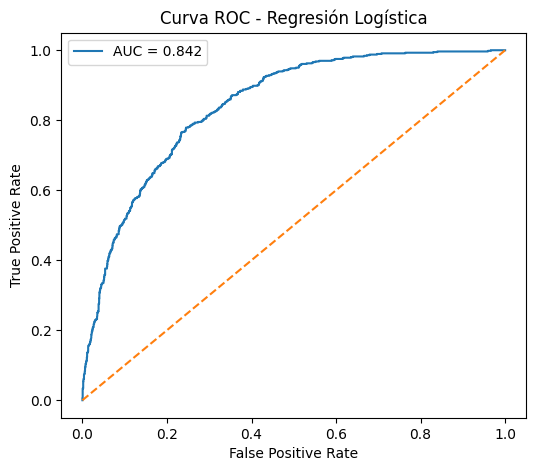

In [299]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades del modelo
y_prob = modelo_lr.predict_proba(X_test)[:,1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular AUC
auc = roc_auc_score(y_test, y_prob)

# Graficar
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")  # línea aleatoria
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()


#### **Curva ROC Random Forest**

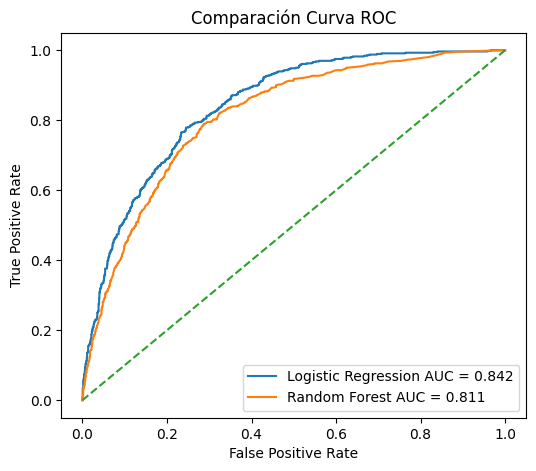

In [300]:
y_prob_rf = modelo_rf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación Curva ROC")
plt.legend()
plt.show()


Evaluación mediante curva ROC

La curva ROC permite evaluar la capacidad del modelo para diferenciar entre clientes que cancelan y aquellos que permanecen en el servicio. El área bajo la curva (AUC) resume el desempeño general del modelo.

Un valor de AUC cercano a 1 indica una excelente capacidad predictiva, mientras que valores cercanos a 0.5 representan un modelo sin capacidad discriminativa.

Algo muy importante para modelos de churn

En problemas de cancelación de clientes, muchas veces se prioriza:

Recall alto

Porque es más importante detectar clientes que se irán que evitar falsos positivos.

Por eso la ROC ayuda a ajustar el umbral de decisión

## **Conclusión del Proyecto**

El presente proyecto tuvo como objetivo analizar los factores asociados a la cancelación de clientes (churn) en una empresa de telecomunicaciones mediante técnicas de análisis de datos y modelos de aprendizaje automático.

Durante la etapa inicial se realizó un proceso de exploración y limpieza de datos, donde se identificaron y corrigieron inconsistencias, valores faltantes y formatos incorrectos. Posteriormente se transformaron y estandarizaron variables para facilitar el análisis, incluyendo la creación de la variable **CargoDiario**, que permitió observar el comportamiento de facturación con mayor detalle.

El análisis exploratorio permitió identificar relaciones importantes entre las variables.
Por ejemplo, se observó que la duración del contrato **(MesesContrato) **presenta una correlación negativa con la cancelación, lo que indica que los clientes con mayor antigüedad tienen menor probabilidad de abandonar el servicio. En contraste, variables relacionadas con costos del servicio, como el **cargo mensual**, muestran una correlación positiva con la cancelación.

Para la fase de modelado predictivo se implementaron dos algoritmos de clasificación:

**Regresión Logística**

**Random Forest**

Ambos modelos fueron evaluados utilizando métricas como accuracy, precision, recall, F1-score y matriz de confusión.

El modelo de **Regresión Logística** obtuvo un accuracy cercano a 0.80, mostrando una buena capacidad para identificar clientes que permanecen en el servicio. Sin embargo, su capacidad para detectar cancelaciones fue moderada, con un recall de aproximadamente 0.53, lo cual es común en problemas donde las clases están desbalanceadas.

Por su parte, el modelo **Random Forest** alcanzó un accuracy cercano a 0.78, con resultados similares en la identificación de clientes activos, aunque con un recall menor para la clase de cancelación. Esto sugiere que ambos modelos presentan un desempeño comparable en la predicción del churn.

El análisis de importancia de variables y coeficientes del modelo permitió identificar los factores más influyentes en la cancelación de clientes. Entre ellos destacan:

**Meses de contrato**

**Cargo mensual**

**Tipo de servicio de internet (fibra)**

**Método de pago**

**Servicios adicionales como streaming y soporte técnico **

Estos resultados sugieren que tanto las características del servicio contratado como las condiciones de facturación y permanencia del cliente influyen significativamente en la decisión de cancelar el servicio.

En conclusión, el uso de modelos de aprendizaje automático permitió identificar patrones relevantes en el comportamiento de los clientes y generar información valiosa para estrategias de retención de clientes. Las empresas de telecomunicaciones podrían utilizar este tipo de modelos para detectar clientes con alto riesgo de cancelación y aplicar medidas preventivas, como ofertas personalizadas, mejoras en el servicio o incentivos de permanencia.

Como trabajo futuro, se podría mejorar el desempeño del modelo mediante optimización de hiperparámetros, técnicas de balanceo de clases y la incorporación de nuevas variables que representen mejor el comportamiento del cliente.